In [1]:
import pandas as pd

In [7]:
df = pd.read_csv('/home/msis/ahegde/aps-lab/datasets/telcochurn.xls')

In [8]:

from sklearn.preprocessing import OrdinalEncoder
binary_encoder = OrdinalEncoder()

In [9]:
df['gender'] = binary_encoder.fit_transform(df[['gender']])
df['Partner'] = binary_encoder.fit_transform(df[['Partner']])
df['Dependents'] = binary_encoder.fit_transform(df[['Dependents']])
df['PhoneService'] = binary_encoder.fit_transform(df[['PhoneService']])
df['PaperlessBilling'] = binary_encoder.fit_transform(df[['PaperlessBilling']])

In [10]:
contract_encoder = OrdinalEncoder(categories=[['Month-to-month', 'One year', 'Two year']])
df['Contract'] = contract_encoder.fit_transform(df[['Contract']])

In [11]:
df = df.drop(columns=['customerID'])

In [12]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0.0,0,1.0,0.0,1,0.0,No phone service,DSL,No,Yes,No,No,No,No,0.0,1.0,Electronic check,29.85,29.85,No
1,1.0,0,0.0,0.0,34,1.0,No,DSL,Yes,No,Yes,No,No,No,1.0,0.0,Mailed check,56.95,1889.5,No
2,1.0,0,0.0,0.0,2,1.0,No,DSL,Yes,Yes,No,No,No,No,0.0,1.0,Mailed check,53.85,108.15,Yes
3,1.0,0,0.0,0.0,45,0.0,No phone service,DSL,Yes,No,Yes,Yes,No,No,1.0,0.0,Bank transfer (automatic),42.30,1840.75,No
4,0.0,0,0.0,0.0,2,1.0,No,Fiber optic,No,No,No,No,No,No,0.0,1.0,Electronic check,70.70,151.65,Yes


In [13]:
cols = ['MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'PaymentMethod', 'Churn']

In [14]:
df[cols] = binary_encoder.fit_transform(df[cols])

In [15]:
df.head(10)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0.0,0,1.0,0.0,1,0.0,1.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,1.0,2.0,29.85,29.85,0.0
1,1.0,0,0.0,0.0,34,1.0,0.0,0.0,2.0,0.0,2.0,0.0,0.0,0.0,1.0,0.0,3.0,56.95,1889.5,0.0
2,1.0,0,0.0,0.0,2,1.0,0.0,0.0,2.0,2.0,0.0,0.0,0.0,0.0,0.0,1.0,3.0,53.85,108.15,1.0
3,1.0,0,0.0,0.0,45,0.0,1.0,0.0,2.0,0.0,2.0,2.0,0.0,0.0,1.0,0.0,0.0,42.30,1840.75,0.0
4,0.0,0,0.0,0.0,2,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,2.0,70.70,151.65,1.0
5,0.0,0,0.0,0.0,8,1.0,2.0,1.0,0.0,0.0,2.0,0.0,2.0,2.0,0.0,1.0,2.0,99.65,820.5,1.0
6,1.0,0,0.0,1.0,22,1.0,2.0,1.0,0.0,2.0,0.0,0.0,2.0,0.0,0.0,1.0,1.0,89.10,1949.4,0.0
7,0.0,0,0.0,0.0,10,0.0,1.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,29.75,301.9,0.0
8,0.0,0,1.0,0.0,28,1.0,2.0,1.0,0.0,0.0,2.0,2.0,2.0,2.0,0.0,1.0,2.0,104.80,3046.05,1.0
9,1.0,0,0.0,1.0,62,1.0,0.0,0.0,2.0,2.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,56.15,3487.95,0.0


In [16]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()

In [17]:
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

In [19]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [21]:
df['TotalCharges'] = df['TotalCharges'].fillna(0)

In [22]:
df[num_cols] = sc.fit_transform(df[num_cols])

In [23]:
df.head(10)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0.0,0,1.0,0.0,-1.277445,0.0,1.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,1.0,2.0,-1.160323,-0.992611,0.0
1,1.0,0,0.0,0.0,0.066327,1.0,0.0,0.0,2.0,0.0,2.0,0.0,0.0,0.0,1.0,0.0,3.0,-0.259629,-0.172165,0.0
2,1.0,0,0.0,0.0,-1.236724,1.0,0.0,0.0,2.0,2.0,0.0,0.0,0.0,0.0,0.0,1.0,3.0,-0.362660,-0.958066,1.0
3,1.0,0,0.0,0.0,0.514251,0.0,1.0,0.0,2.0,0.0,2.0,2.0,0.0,0.0,1.0,0.0,0.0,-0.746535,-0.193672,0.0
4,0.0,0,0.0,0.0,-1.236724,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,2.0,0.197365,-0.938874,1.0
5,0.0,0,0.0,0.0,-0.992402,1.0,2.0,1.0,0.0,0.0,2.0,0.0,2.0,2.0,0.0,1.0,2.0,1.159546,-0.643789,1.0
6,1.0,0,0.0,1.0,-0.422317,1.0,2.0,1.0,0.0,2.0,0.0,0.0,2.0,0.0,0.0,1.0,1.0,0.808907,-0.145738,0.0
7,0.0,0,0.0,0.0,-0.910961,0.0,1.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,-1.163647,-0.872587,0.0
8,0.0,0,1.0,0.0,-0.177995,1.0,2.0,1.0,0.0,0.0,2.0,2.0,2.0,2.0,0.0,1.0,2.0,1.330711,0.338085,1.0
9,1.0,0,0.0,1.0,1.206498,1.0,0.0,0.0,2.0,2.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,-0.286218,0.533044,0.0


In [24]:
x = df.iloc[:, :-1].values
x

array([[ 0.        ,  0.        ,  1.        , ...,  2.        ,
        -1.16032292, -0.99261052],
       [ 1.        ,  0.        ,  0.        , ...,  3.        ,
        -0.25962894, -0.17216471],
       [ 1.        ,  0.        ,  0.        , ...,  3.        ,
        -0.36266036, -0.9580659 ],
       ...,
       [ 0.        ,  0.        ,  1.        , ...,  2.        ,
        -1.1686319 , -0.85293201],
       [ 1.        ,  1.        ,  1.        , ...,  3.        ,
         0.32033821, -0.87051315],
       [ 1.        ,  0.        ,  0.        , ...,  0.        ,
         1.35896134,  2.01389665]], shape=(7043, 19))

In [25]:
y = df.iloc[:, -1].values
y

array([0., 0., 1., ..., 0., 1., 0.], shape=(7043,))

In [26]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=67)

In [40]:
df[df['Churn']==0]

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0.0,0,1.0,0.0,-1.277445,0.0,1.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,1.0,2.0,-1.160323,-0.992611,0.0
1,1.0,0,0.0,0.0,0.066327,1.0,0.0,0.0,2.0,0.0,2.0,0.0,0.0,0.0,1.0,0.0,3.0,-0.259629,-0.172165,0.0
3,1.0,0,0.0,0.0,0.514251,0.0,1.0,0.0,2.0,0.0,2.0,2.0,0.0,0.0,1.0,0.0,0.0,-0.746535,-0.193672,0.0
6,1.0,0,0.0,1.0,-0.422317,1.0,2.0,1.0,0.0,2.0,0.0,0.0,2.0,0.0,0.0,1.0,1.0,0.808907,-0.145738,0.0
7,0.0,0,0.0,0.0,-0.910961,0.0,1.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,-1.163647,-0.872587,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7037,0.0,0,0.0,0.0,1.613701,1.0,0.0,2.0,1.0,1.0,1.0,1.0,1.0,1.0,2.0,1.0,0.0,-1.449476,-0.379565,0.0
7038,1.0,0,1.0,1.0,-0.340876,1.0,2.0,0.0,2.0,0.0,2.0,2.0,2.0,2.0,1.0,1.0,3.0,0.665992,-0.127605,0.0
7039,0.0,0,1.0,1.0,1.613701,1.0,2.0,1.0,0.0,2.0,2.0,0.0,2.0,2.0,1.0,1.0,1.0,1.277533,2.242606,0.0
7040,0.0,0,1.0,1.0,-0.870241,0.0,1.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,2.0,-1.168632,-0.852932,0.0


In [30]:
from sklearn.linear_model import LogisticRegression

In [31]:
model = LogisticRegression(class_weight='balanced', random_state=67)

In [32]:
model.fit(x_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,67
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [33]:
y_preds = model.predict(x_test)

In [36]:
from sklearn.metrics import accuracy_score

acc = accuracy_score(y_test, y_preds)*100

acc

74.02413058907025

In [37]:
from sklearn.metrics import roc_auc_score

rocscore = roc_auc_score(y_test, y_preds)

rocscore

0.7648956575111248

In [38]:
from sklearn.metrics import recall_score

recall = recall_score(y_test, y_preds)

recall

0.8184210526315789

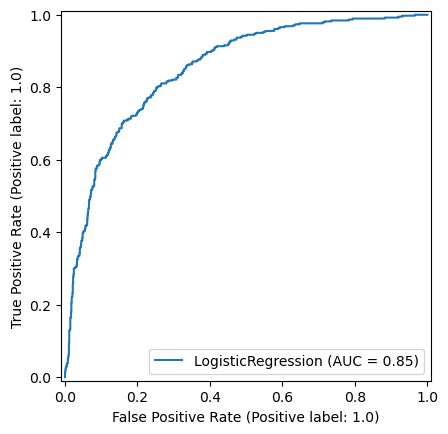

In [39]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_estimator(model, x_test, y_test)

In [41]:
import numpy as np

In [42]:
y_train_np = np.array(y_train)

In [43]:
y_test_np = np.array(y_test)

In [48]:
y_train_np[y_train_np==0]

array([0., 0., 0., ..., 0., 0., 0.], shape=(4145,))